<a href="https://colab.research.google.com/github/nouramar228-cyber/Time-Series-Analysis/blob/main/(Core)_Resampling_Datetime_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# (Core) Resampling Datetime Data
For this assignment, you will be working with a modified version of [weather data from London from Kaggle](https://www.kaggle.com/datasets/emmanuelfwerr/london-weather-data).
The assignment is split into 2 parts:

* ## Part 1: Load the data and create a datetime index

* ## Part 2: Answer 2 Questions using visualizations and the correct frequency data

# Part 1) Load the data and make a datetime index.
* Use the modified version of the data provided here:

 * Share URL: https://docs.google.com/spreadsheets/d/1J2hEGA1-ZOdXOc1Go2AjB7xShq-nAvIDpBz_XRZscHU/edit?usp=sharing
 * Raw URL:
   * https://docs.google.com/spreadsheets/d/e/2PACX-1vT_jChgNsQbHbg4TGepzIqk8XC9DTIKmyyxb1upo5cfZCgbfIUQc2ZC0YMzuU5uApP140Ob49KBjdqh/pub?gid=1198589591&single=true&output=csv

# Part 2) Answer the Questions with Visualizations (Using the Correct Frequency)

Q1: What month had the most precipitation between 2000 through 2010?
Q2: Which year between 2000-2020 had the coolest average temperature?

##Part1) Load Data + Create Datetime Index

#### Import neccesary libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [ ]:
fpath="/content/drive/MyDrive/AXSOSACADEMY/AXSOSACADEMY/03-DataEnrichment/Week09/Data/london_weather_MODIFIED - london_weather_MODIFIED.csv"
df = pd.read_csv(fpath)
df.head()

,date,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth
0,19790101,2.0,7.0,52.0,2.3,-4.1,-7.5,0.4,101900.0,9.0
1,19790102,6.0,1.7,27.0,1.6,-2.6,-7.5,0.0,102530.0,8.0
2,19790103,5.0,0.0,13.0,1.3,-2.8,-7.2,0.0,102050.0,4.0
3,19790104,8.0,0.0,13.0,-0.3,-2.6,-6.5,0.0,100840.0,2.0
4,19790105,6.0,2.0,29.0,5.6,-0.8,-1.4,0.0,102250.0,1.0


In [ ]:
# check Columns
df.columns

Index(['date', 'cloud_cover', 'sunshine', 'global_radiation', 'max_temp',
       'mean_temp', 'min_temp', 'precipitation', 'pressure', 'snow_depth'],
      dtype='object')

## convert data column to datetime

In [ ]:
df['date'] = pd.to_datetime(df['date'], format='%Y%m%d')

In [ ]:
df['date'] = pd.to_datetime(df['date'])

In [ ]:
# Set date as index
df = df.set_index('date')

In [ ]:
df.index

DatetimeIndex(['1979-01-01', '1979-01-02', '1979-01-03', '1979-01-04',
               '1979-01-05', '1979-01-06', '1979-01-07', '1979-01-08',
               '1979-01-09', '1979-01-10',
               ...
               '2020-12-22', '2020-12-23', '2020-12-24', '2020-12-25',
               '2020-12-26', '2020-12-27', '2020-12-28', '2020-12-29',
               '2020-12-30', '2020-12-31'],
              dtype='datetime64[ns]', name='date', length=15341, freq=None)

In [ ]:
df.head()

,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth
date,,,,,,,,,
1979-01-01,2.0,7.0,52.0,2.3,-4.1,-7.5,0.4,101900.0,9.0
1979-01-02,6.0,1.7,27.0,1.6,-2.6,-7.5,0.0,102530.0,8.0
1979-01-03,5.0,0.0,13.0,1.3,-2.8,-7.2,0.0,102050.0,4.0
1979-01-04,8.0,0.0,13.0,-0.3,-2.6,-6.5,0.0,100840.0,2.0
1979-01-05,6.0,2.0,29.0,5.6,-0.8,-1.4,0.0,102250.0,1.0


In [ ]:
# Keep only year 2000 and later
df = df.loc['2000':]

In [ ]:
#Keep required features only
df = df[['precipitation',
         'mean_temp',
         'min_temp',
         'max_temp',
         'snow_depth']]

In [ ]:
#check missing value
df.isna().sum()

,0
precipitation,390
mean_temp,419
min_temp,386
max_temp,390
snow_depth,1752


In [ ]:
# Imputation
df['mean_temp'] = df['mean_temp'].interpolate()

df['min_temp'] = df['min_temp'].interpolate()

df['max_temp'] = df['max_temp'].interpolate()

In [ ]:
df['precipitation'] = df['precipitation'].fillna(0)

df['snow_depth'] = df['snow_depth'].fillna(0)

In [ ]:
df.isna().sum()

,0
precipitation,0
mean_temp,0
min_temp,0
max_temp,0
snow_depth,0


# Q1: What month had the most precipitation between 2000-2010?

In [ ]:
# Resample precipitation monthly using sum
precip_monthly = df['precipitation'].resample('MS').sum()

In [ ]:
precip_2000_2010 = precip_monthly.loc['2000':'2010']

In [ ]:
precip_monthly.head()

,precipitation
date,
2000-01-01,14.3
2000-02-01,62.2
2000-03-01,13.4
2000-04-01,71.8
2000-05-01,68.4


In [ ]:
# Find maximum precipitation
max_date = precip_2000_2010.idxmax()

max_value = precip_2000_2010.max()

print(max_date)
print(max_value)

2009-11-01 00:00:00
138.4


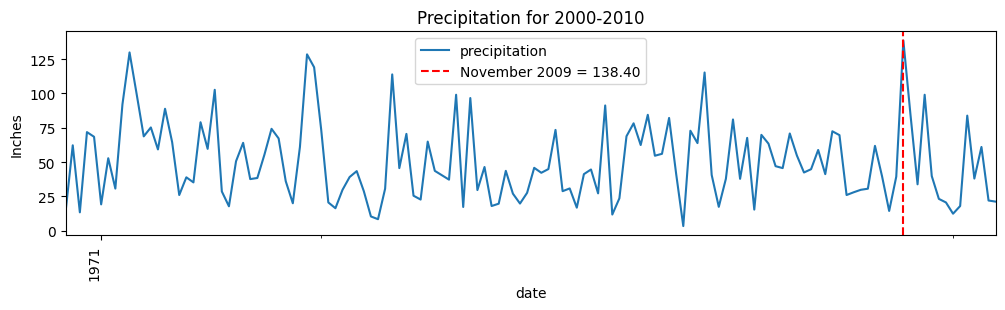

In [ ]:
fig, ax = plt.subplots(figsize=(12,3))

precip_2000_2010.plot(ax=ax)

ax.set_title('Precipitation for 2000-2010')
ax.set_ylabel('Inches')


ax.axvline(
    max_date,
    color='red',
    linestyle='--',
    label=f"{max_date.strftime('%B %Y')} = {max_value:.2f}"
)


ax.xaxis.set_major_locator(
    mdates.YearLocator(1)
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter('%Y')
)

ax.xaxis.set_minor_locator(
    mdates.MonthLocator(interval=3)
)


fig.autofmt_xdate(rotation=90)

ax.legend()

plt.show()

# Q2: Q2: Which year between 2000-2020 had the coolest average temperature?

In [ ]:
# Resample yearly using mean
temp_yearly = df['mean_temp'].resample('YS').mean()

In [ ]:
# Select period
temp_2000_2020 = temp_yearly.loc['2000':'2020']

In [ ]:
# Find coolest year
coolest_date = temp_2000_2020.idxmin()

coolest_value = temp_2000_2020.min()

print(coolest_date)
print(coolest_value)

2010-01-01 00:00:00
10.657397260273973


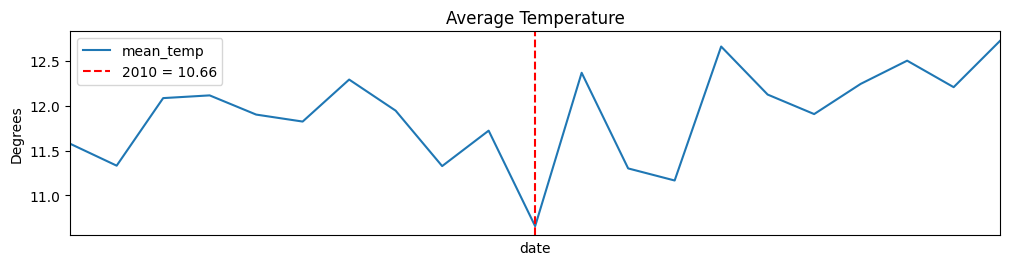

In [ ]:
fig, ax = plt.subplots(figsize=(12,3))


temp_2000_2020.plot(ax=ax)


ax.set_title('Average Temperature')

ax.set_ylabel('Degrees')


# vertical line
ax.axvline(
    coolest_date,
    color='red',
    linestyle='--',
    label=f"{coolest_date.strftime('%Y')} = {coolest_value:.2f}"
)


# major ticks every 5 years
ax.xaxis.set_major_locator(
    mdates.YearLocator(5)
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter('%Y')
)


# minor ticks every year
ax.xaxis.set_minor_locator(
    mdates.YearLocator(1)
)


fig.autofmt_xdate(rotation=90)


ax.legend()

plt.show()